# 02 Rolling OLS Baseline

This notebook builds a causal rolling hedge-ratio model for the selected pair.  
The hedge ratio and z-score inputs are lagged so the signal at time `t` only uses information available through `t-1`.

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.tsa.stattools import adfuller, coint

In [134]:
import importlib
import pipeline_config as cfg

# Reload shared config so notebook picks up edits without a kernel restart.
cfg = importlib.reload(cfg)

BAR_INTERVAL = cfg.BAR_INTERVAL
DATA_PATH = cfg.DATA_PATH
ENTRY_Z = cfg.ENTRY_Z
EXIT_Z = cfg.EXIT_Z
PAIR_X = cfg.PAIR_X
PAIR_Y = cfg.PAIR_Y
RESULTS_TABLES_PATH = cfg.RESULTS_TABLES_PATH
ROLLING_WINDOW = cfg.ROLLING_WINDOW
ensure_project_dirs = cfg.ensure_project_dirs
get_trade_stats = cfg.get_trade_stats
make_position = cfg.make_position

ensure_project_dirs()

data_path = DATA_PATH
results_path = RESULTS_TABLES_PATH

log_prices = pd.read_csv(data_path / "equity_log_prices.csv", index_col=0, parse_dates=True)
log_prices.index.name = "Datetime"

log_prices.head()

,CVX,XOM
Datetime,,
2025-06-26,4.940952,4.675775
2025-07-01,4.948745,4.668933
2025-07-11,5.013511,4.724050
2025-07-16,4.978190,4.695936
2025-07-21,4.976588,4.657980


In [135]:
universe = pd.read_csv(data_path / "universe_metadata.csv")

assert {"ticker", "sleeve"}.issubset(universe.columns)
assert set(universe["ticker"]) == {PAIR_Y, PAIR_X}
assert len(universe) == 2

missing_tickers = set(universe["ticker"]) - set(log_prices.columns)
assert not missing_tickers, f"Missing price series for: {sorted(missing_tickers)}"

universe

,ticker,sleeve
0,CVX,selected_pair
1,XOM,selected_pair


In [136]:
pair_data = log_prices[[PAIR_Y, PAIR_X]].dropna().copy()
pair_data.columns = ["y", "x"]
pair_data.index.name = "Datetime"

assert pair_data.index.is_monotonic_increasing
assert pair_data.index.is_unique

pair_data.head()

,y,x
Datetime,,
2025-06-26,4.940952,4.675775
2025-07-01,4.948745,4.668933
2025-07-11,5.013511,4.724050
2025-07-16,4.978190,4.695936
2025-07-21,4.976588,4.657980


In [137]:
X = sm.add_constant(pair_data["x"])
rolling_ols_model = RollingOLS(pair_data["y"], X, window=ROLLING_WINDOW)
rolling_ols_fit = rolling_ols_model.fit()


In [138]:
pair_data["rolling_alpha_raw"] = rolling_ols_fit.params["const"]
pair_data["rolling_beta_raw"] = rolling_ols_fit.params["x"]

# Lag the hedge ratio so the spread at t only uses parameters estimated through t-1.
pair_data["alpha"] = pair_data["rolling_alpha_raw"].shift(1)
pair_data["beta"] = pair_data["rolling_beta_raw"].shift(1)

pair_data["y_hat"] = pair_data["alpha"] + (pair_data["beta"] * pair_data["x"])
pair_data["spread"] = pair_data["y"] - pair_data["y_hat"]

pair_data[["alpha", "beta", "spread"]].tail()

,alpha,beta,spread
Datetime,,,
2026-02-26,1.431267,0.751651,0.025640
2026-03-03,1.326393,0.773831,0.027368
2026-03-13,1.303068,0.779513,0.042193
2026-03-18,1.225191,0.796607,0.035322
2026-03-23,1.131663,0.816427,0.032102


In [139]:
valid_spread = pair_data["spread"].dropna()
valid_pair_data = pair_data.loc[valid_spread.index, ["y", "x"]]

assert len(valid_spread) > ROLLING_WINDOW

adf_result = adfuller(valid_spread)
coint_stat, coint_pvalue, coint_crit_values = coint(valid_pair_data["y"], valid_pair_data["x"])


In [140]:
diagnostics = pd.Series(
    {
        "spread_adf_stat": adf_result[0],
        "spread_adf_pvalue": adf_result[1],
        "spread_adf_1pct_crit": adf_result[4]["1%"],
        "spread_adf_5pct_crit": adf_result[4]["5%"],
        "pair_coint_stat": coint_stat,
        "pair_coint_pvalue": coint_pvalue,
        "pair_coint_1pct_crit": coint_crit_values[0],
        "pair_coint_5pct_crit": coint_crit_values[1],
        "spread_obs": len(valid_spread),
    }
)

diagnostics.to_frame("value")


,value
spread_adf_stat,-2.800468
spread_adf_pvalue,0.058207
spread_adf_1pct_crit,-3.688926
spread_adf_5pct_crit,-2.971989
pair_coint_stat,-1.584068
pair_coint_pvalue,0.727568
pair_coint_1pct_crit,-4.330343
pair_coint_5pct_crit,-3.563051
spread_obs,29.000000


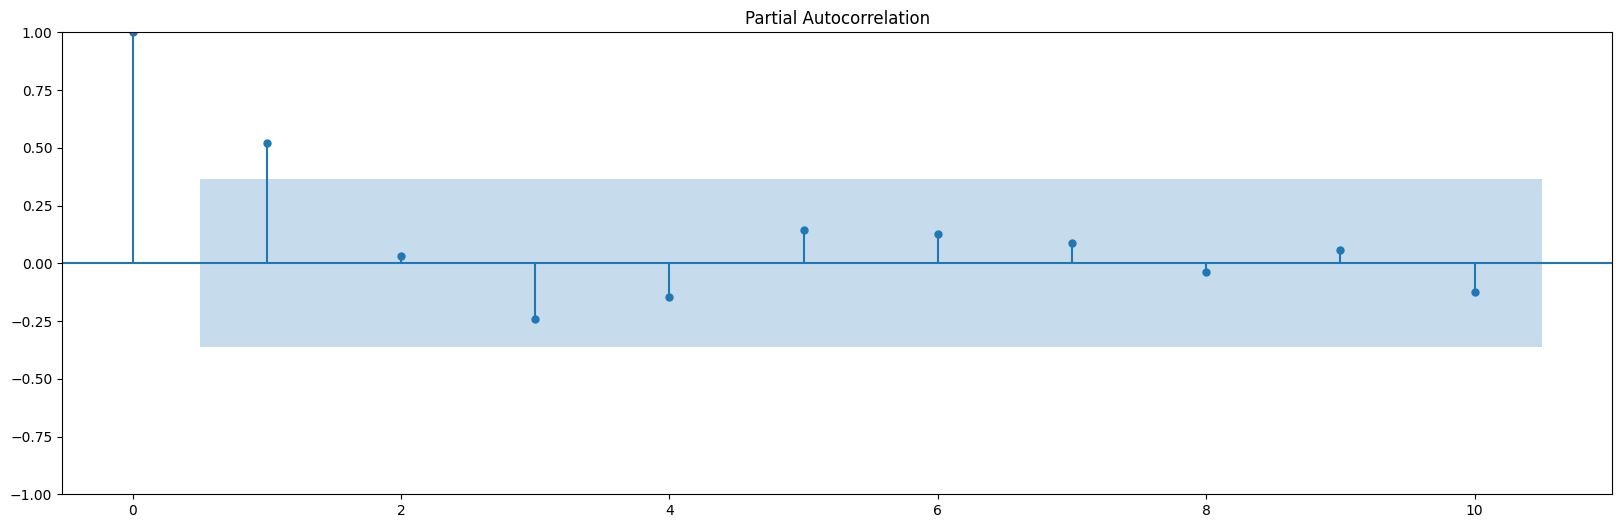

In [141]:
from statsmodels.graphics.tsaplots import plot_pacf
clean_spread = pair_data["spread"].dropna()
plot_pacf(clean_spread, lags=10)
plt.gcf().set_size_inches(20, 6)
plt.show()

In [142]:
z_lag = pair_data['spread'].shift(1)
z_delta = pair_data['spread'].diff()
data = pd.DataFrame({'delta': z_delta, 'lag': z_lag}).dropna()
X = sm.add_constant(data['lag'])
model = sm.OLS(data['delta'], X).fit()
lambda_val = model.params['lag'] #decay-constant
if lambda_val < 0:
    half_life = -np.log(2) / lambda_val # half-Life: -ln(2) / lambda
    print(f"Mean Reversion")
    print(f"Half-Life: {half_life:.2f} bars")
else:
    print("Spread is divergent")

Mean Reversion
Half-Life: 1.54 bars


In [143]:
# Shift the rolling moments so the z-score at t only uses spread history through t-1.
pair_data["spread_mean"] = pair_data["spread"].rolling(ROLLING_WINDOW).mean().shift(1)
pair_data["spread_std"] = pair_data["spread"].rolling(ROLLING_WINDOW).std().shift(1)
pair_data["spread_std"] = pair_data["spread_std"].replace(0, np.nan)
pair_data["zscore"] = (pair_data["spread"] - pair_data["spread_mean"]) / pair_data["spread_std"]
pair_data["signal"] = make_position(pair_data["zscore"])

pair_data.tail()


,y,x,rolling_alpha_raw,rolling_beta_raw,alpha,beta,y_hat,spread,spread_mean,spread_std,zscore,signal
Datetime,,,,,,,,,,,,
2026-02-26,5.215805,5.000854,1.326393,0.773831,1.431267,0.751651,5.190165,0.025640,-0.003762,0.026848,1.095129,0
2026-03-03,5.240529,5.022761,1.303068,0.779513,1.326393,0.773831,5.213161,0.027368,0.001469,0.026984,0.959790,0
2026-03-13,5.282290,5.050625,1.225191,0.796607,1.303068,0.779513,5.240097,0.042193,0.007252,0.025538,1.368176,0
2026-03-18,5.291343,5.059997,1.131663,0.816427,1.225191,0.796607,5.256021,0.035322,0.012499,0.026891,0.848735,0
2026-03-23,5.323741,5.095344,0.729758,0.897432,1.131663,0.816427,5.291640,0.032102,0.012949,0.027267,0.702413,0


In [144]:
required_columns = [
    "y",
    "x",
    "rolling_alpha_raw",
    "rolling_beta_raw",
    "alpha",
    "beta",
    "y_hat",
    "spread",
    "spread_mean",
    "spread_std",
    "zscore",
    "signal",
]

assert all(column in pair_data.columns for column in required_columns)
assert pair_data["zscore"].notna().any()

pair_data.tail()


,y,x,rolling_alpha_raw,rolling_beta_raw,alpha,beta,y_hat,spread,spread_mean,spread_std,zscore,signal
Datetime,,,,,,,,,,,,
2026-02-26,5.215805,5.000854,1.326393,0.773831,1.431267,0.751651,5.190165,0.025640,-0.003762,0.026848,1.095129,0
2026-03-03,5.240529,5.022761,1.303068,0.779513,1.326393,0.773831,5.213161,0.027368,0.001469,0.026984,0.959790,0
2026-03-13,5.282290,5.050625,1.225191,0.796607,1.303068,0.779513,5.240097,0.042193,0.007252,0.025538,1.368176,0
2026-03-18,5.291343,5.059997,1.131663,0.816427,1.225191,0.796607,5.256021,0.035322,0.012499,0.026891,0.848735,0
2026-03-23,5.323741,5.095344,0.729758,0.897432,1.131663,0.816427,5.291640,0.032102,0.012949,0.027267,0.702413,0


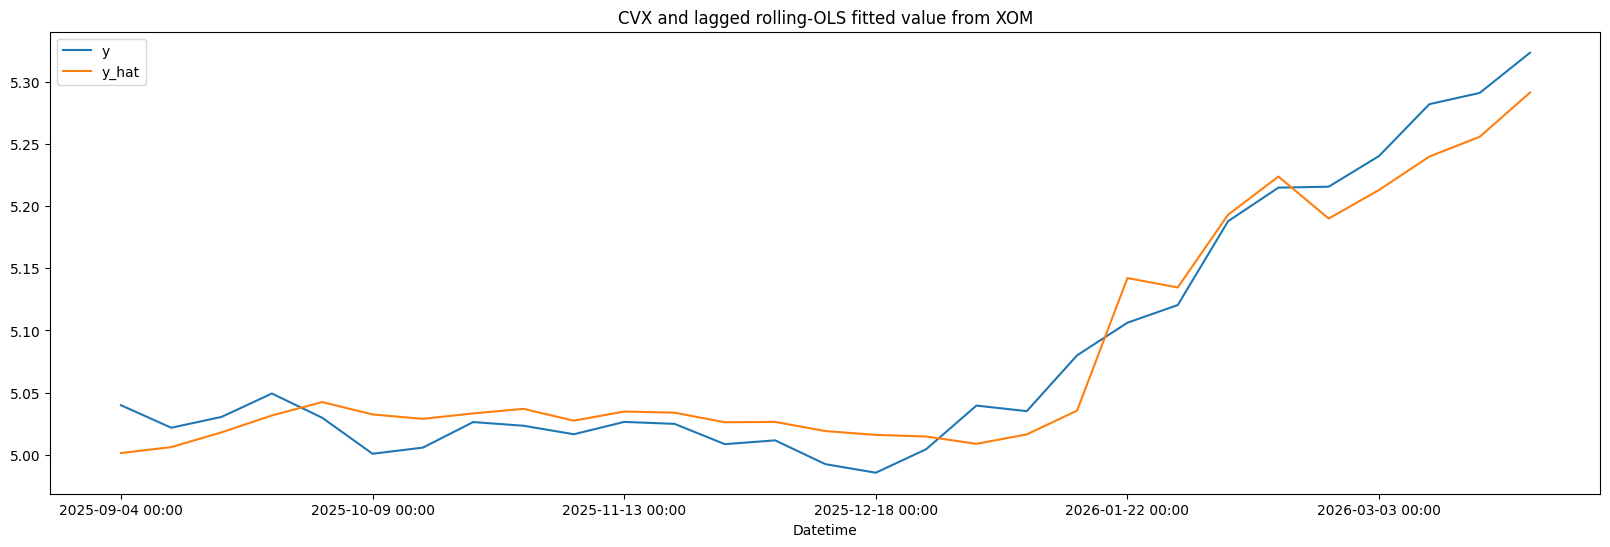

In [145]:
plot_pair = pair_data[["y", "y_hat"]].dropna().copy()
plot_pair.index = plot_pair.index.strftime("%Y-%m-%d %H:%M")
plot_pair.plot(title=f"{PAIR_Y} and lagged rolling-OLS fitted value from {PAIR_X}", figsize=(20, 6))
plt.show()

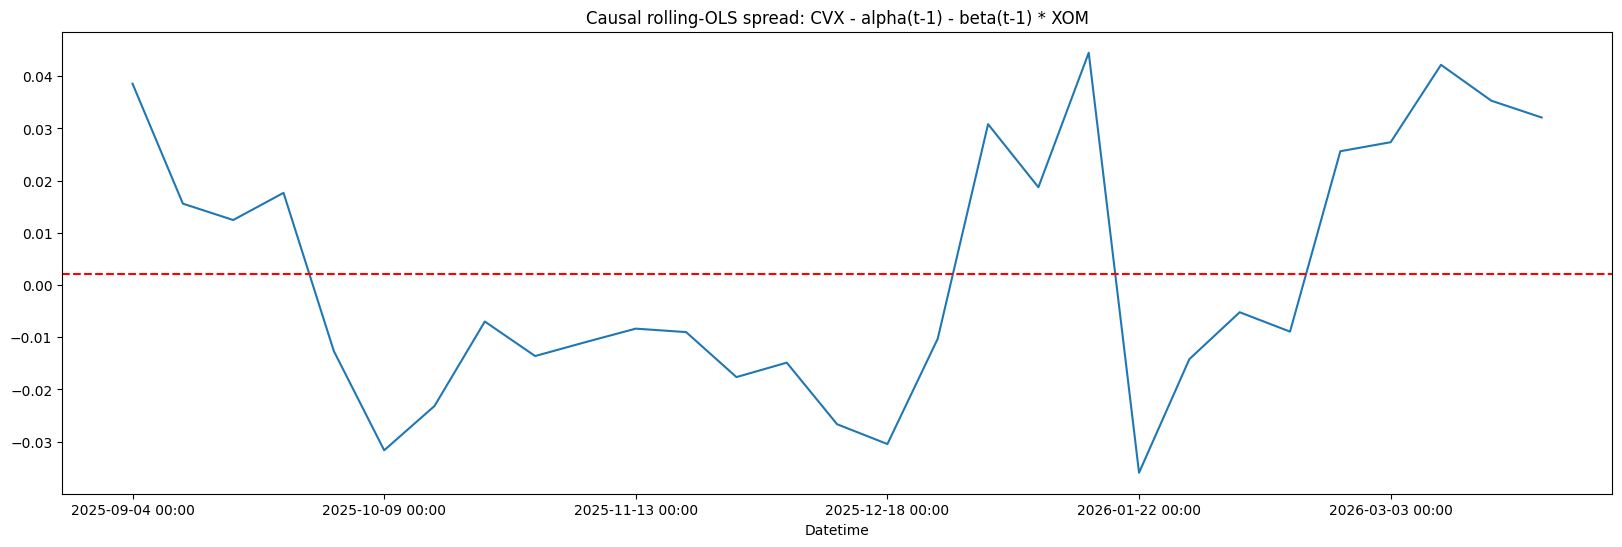

In [146]:
plot_spread = pair_data["spread"].copy()
plot_spread.index = plot_spread.index.strftime("%Y-%m-%d %H:%M")
plot_spread.plot(
    title=f"Causal rolling-OLS spread: {PAIR_Y} - alpha(t-1) - beta(t-1) * {PAIR_X}",
    figsize=(20, 6)
)
plt.axhline(pair_data["spread"].mean(), linestyle="--", color="red")
plt.show()


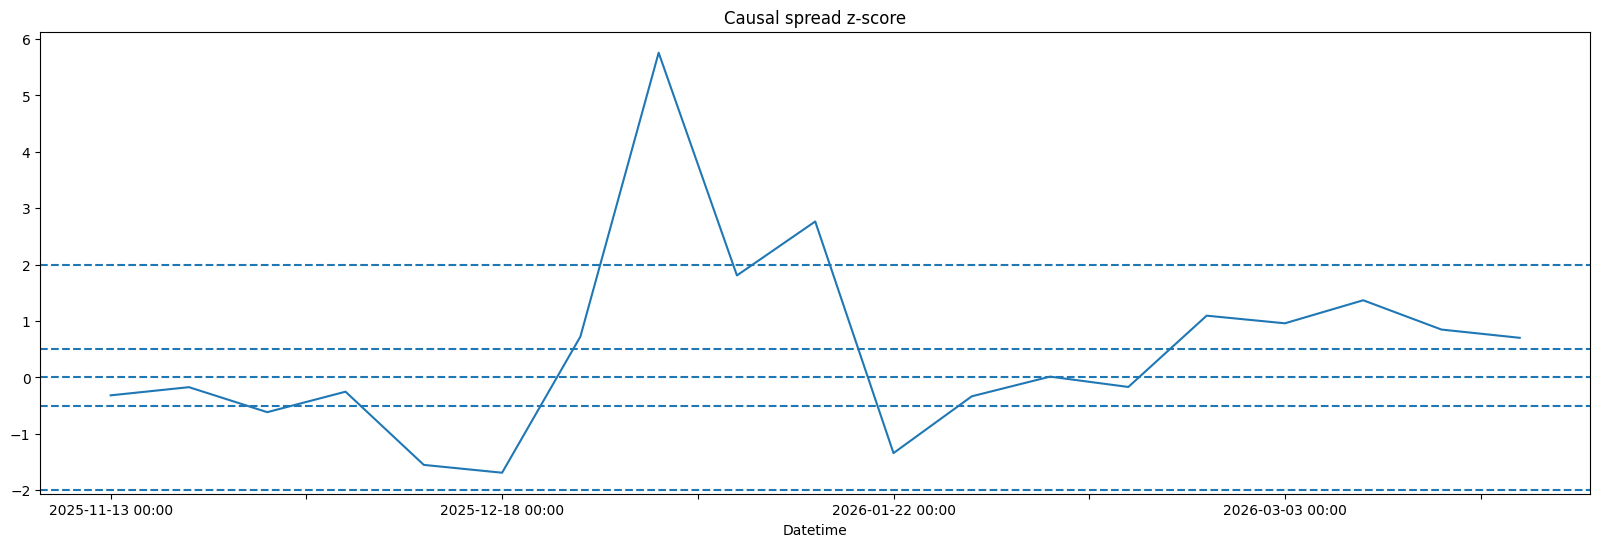

In [147]:
plot_z = pair_data["zscore"].copy()
plot_z.index = plot_z.index.strftime("%Y-%m-%d %H:%M")
plot_z.plot(title="Causal spread z-score", figsize=(20, 6))
for level in [ENTRY_Z, -ENTRY_Z, EXIT_Z, -EXIT_Z, 0]:
    plt.axhline(level, linestyle="--")
plt.show()


In [148]:
signal_frame = pair_data.dropna(subset=["alpha", "beta", "spread", "zscore"]).copy()
assert not signal_frame.empty

latest_row = signal_frame.iloc[-1]
first_signal_timestamp = signal_frame.index[0]
effective_warmup_bars = int(pair_data.index.get_loc(first_signal_timestamp))

summary = pd.DataFrame(
    {
        "ticker_y": [PAIR_Y],
        "ticker_x": [PAIR_X],
        "model_type": ["rolling_ols_lagged"],
        "alpha": [latest_row["alpha"]],
        "beta": [latest_row["beta"]],
        "latest_alpha": [latest_row["alpha"]],
        "latest_beta": [latest_row["beta"]],
        "beta_mean": [pair_data["beta"].mean(skipna=True)],
        "n_obs_total": [len(pair_data)],
        "n_obs_signal": [len(signal_frame)],
        "effective_warmup_bars": [effective_warmup_bars],
        "rolling_window": [ROLLING_WINDOW],
        "entry_z": [ENTRY_Z],
        "exit_z": [EXIT_Z],
        "bar_interval": [BAR_INTERVAL],
        "first_signal_timestamp": [first_signal_timestamp],
        "latest_spread": [latest_row["spread"]],
        "latest_zscore": [latest_row["zscore"]],
        "spread_adf_pvalue": [adf_result[1]],
        "pair_coint_pvalue": [coint_pvalue],
    }
)

summary


,ticker_y,ticker_x,model_type,alpha,beta,latest_alpha,latest_beta,beta_mean,n_obs_total,n_obs_signal,effective_warmup_bars,rolling_window,entry_z,exit_z,bar_interval,first_signal_timestamp,latest_spread,latest_zscore,spread_adf_pvalue,pair_coint_pvalue
0,CVX,XOM,rolling_ols_lagged,1.131663,0.816427,1.131663,0.816427,0.446223,39,19,20,10,2.0,0.5,5d,2025-11-13,0.032102,0.702413,0.058207,0.727568


In [149]:
rolling_output_file = results_path / f"{PAIR_Y}_{PAIR_X}_rolling_ols.csv"
rolling_summary_file = results_path / f"{PAIR_Y}_{PAIR_X}_rolling_ols_summary.csv"

pair_data.to_csv(rolling_output_file, index_label="Datetime")
summary.to_csv(rolling_summary_file, index=False)

print(f"Saved: {rolling_output_file.name}, {rolling_summary_file.name}")

Saved: CVX_XOM_rolling_ols.csv, CVX_XOM_rolling_ols_summary.csv


In [150]:
get_trade_stats(pair_data)

{'Total Trades': 1,
 'Gross PnL': np.float64(0.06678),
 'Net PnL': np.float64(0.06578),
 'Avg Profit/Trade (Gross)': np.float64(0.06678),
 'Fee (Round-trip)': 0.001}